# Group Splitter Embeddings

This notebook compares:
- **Input space** (per-hit input features used by the model)
- **Model embedding space** (true latent vectors from `model.extract_embeddings(...)`)

It uses a trained exported group-splitter model and aligned group-classifier probabilities.


In [1]:
import json
import re
from pathlib import Path
from datetime import datetime

import numpy as np
import pyarrow.parquet as pq
import torch

from pioneerml.data_loader import DataFlowConfig, InputSourceSet, SplitSampleConfig
from pioneerml.evaluation.plots import plot_embedding_space
from pioneerml.integration.zenml import utils as zenml_utils

PROJECT_ROOT = zenml_utils.find_project_root()
zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)

from pioneerml_base_plugin.group_splitter.loader import GroupSplitterGraphLoader
from pioneerml_base_plugin.group_splitter.model import GroupSplitter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")


Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).
Project root: /workspace
Device: cuda


## Inputs

In [2]:
data_dir = Path(PROJECT_ROOT) / "data"
parquet_paths = sorted(data_dir.glob("ml_output_*.parquet"))

# Optional quick subset
# parquet_paths = parquet_paths[:1]

parquet_paths = [p.resolve() for p in parquet_paths]
if not parquet_paths:
    raise RuntimeError(f"No parquet files found in {data_dir}")

pred_dir = Path(PROJECT_ROOT) / "data" / "group_classifier"


def _pick_pred_path(main_path: Path) -> Path | None:
    stem = main_path.stem
    candidates = [
        pred_dir / f"{stem}_preds.parquet",
        pred_dir / f"{stem}_preds_latest.parquet",
        pred_dir / "group_classifier_preds_latest.parquet",
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    return None


pred_paths = [_pick_pred_path(p) for p in parquet_paths]
if all(p is not None for p in pred_paths):
    group_probs_parquet_paths = [str(p) for p in pred_paths]  # type: ignore[arg-type]
else:
    # Fallback: if pred columns are already in main parquet files
    required_pred_cols = {"pred_pion", "pred_muon", "pred_mip"}
    schemas_ok = all(required_pred_cols.issubset(set(pq.read_schema(str(p)).names)) for p in parquet_paths)
    if schemas_ok:
        group_probs_parquet_paths = None
    else:
        raise RuntimeError(
            "Could not resolve group-classifier prediction files. "
            "Expected either data/group_classifier/<input_stem>_preds.parquet for each input "
            "or pred_pion/pred_muon/pred_mip columns in main parquet files."
        )

# Latest model artifacts
model_dir = Path(PROJECT_ROOT) / "trained_models" / "groupsplitter"
meta_candidates = sorted(model_dir.glob("*_meta.json"), key=lambda p: p.stat().st_mtime, reverse=True)
if not meta_candidates:
    raise RuntimeError(f"No metadata files found in {model_dir}")

meta_path = meta_candidates[0]
meta = json.loads(meta_path.read_text())
torchscript_path = Path(meta.get("torchscript_path") or str(meta_path).replace("_meta.json", "_torchscript.pt"))
if not torchscript_path.exists():
    raise FileNotFoundError(f"TorchScript file not found: {torchscript_path}")

print(f"Using metadata:    {meta_path}")
print(f"Using torchscript: {torchscript_path}")
print(f"Num parquet files: {len(parquet_paths)}")
print(f"Using external group_probs files: {group_probs_parquet_paths is not None}")


Using metadata:    /workspace/trained_models/groupsplitter/groupsplitter_20260326_012855_meta.json
Using torchscript: /workspace/trained_models/groupsplitter/groupsplitter_20260326_012855_torchscript.pt
Num parquet files: 5
Using external group_probs files: True


## Rebuild Eager Model

In [3]:
def _strip_prefix(state_dict: dict[str, torch.Tensor], prefix: str = "model.") -> dict[str, torch.Tensor]:
    out: dict[str, torch.Tensor] = {}
    for key, value in state_dict.items():
        out[key[len(prefix):] if key.startswith(prefix) else key] = value
    return out


def _infer_group_splitter_cfg(
    state: dict[str, torch.Tensor],
    *,
    meta: dict,
) -> dict:
    hpo_params = dict(meta.get("hpo_params") or {})
    best_params = dict(hpo_params.get("best_params") or {})
    model_cfg = dict(hpo_params.get("model") or {})
    data_shapes = dict(meta.get("data_shapes") or {})

    input_proj_weight = state.get("input_proj.weight")
    if not isinstance(input_proj_weight, torch.Tensor) or input_proj_weight.dim() != 2:
        raise RuntimeError("TorchScript state is missing input_proj.weight for GroupSplitter inference.")

    hidden_from_state = int(input_proj_weight.shape[0])
    input_dim_total = int(input_proj_weight.shape[1])

    node_dim = int(best_params.get("node_dim", model_cfg.get("node_dim", model_cfg.get("in_channels", data_shapes.get("x_dim", 4)))))
    if node_dim <= 0 or node_dim > input_dim_total:
        node_dim = int(data_shapes.get("x_dim", 4) or 4)
    if node_dim <= 0 or node_dim > input_dim_total:
        node_dim = input_dim_total

    graph_dim = int(best_params.get("graph_dim", model_cfg.get("graph_dim", model_cfg.get("prob_dimension", input_dim_total - node_dim))))
    if graph_dim < 0 or (node_dim + graph_dim) != input_dim_total:
        graph_dim = input_dim_total - node_dim
    if graph_dim < 0:
        graph_dim = 0
        node_dim = input_dim_total

    edge_weight = state.get("blocks.0.attn.lin_edge.weight")
    edge_dim = int(edge_weight.shape[1]) if isinstance(edge_weight, torch.Tensor) and edge_weight.dim() == 2 else 4

    block_idxs = [
        int(match.group(1))
        for key in state.keys()
        for match in [re.match(r"^blocks\.(\d+)\.", key)]
        if match
    ]
    inferred_layers = (max(block_idxs) + 1) if block_idxs else int(model_cfg.get("layers", 3))

    node_head_weight = state.get("node_head.weight")
    inferred_num_classes = (
        int(node_head_weight.shape[0])
        if isinstance(node_head_weight, torch.Tensor) and node_head_weight.dim() == 2
        else int(data_shapes.get("num_classes", 3) or 3)
    )

    hidden = hidden_from_state
    heads = int(best_params.get("heads", model_cfg.get("heads", 4)))
    if heads <= 0 or hidden % heads != 0:
        valid_divisors = [h for h in (8, 6, 4, 3, 2, 1) if hidden % h == 0]
        heads = int(valid_divisors[0] if valid_divisors else 1)

    cfg = {
        "node_dim": int(node_dim),
        "edge_dim": int(edge_dim),
        "graph_dim": int(graph_dim),
        "hidden": int(hidden),
        "heads": int(heads),
        "layers": int(inferred_layers),
        "dropout": float(best_params.get("dropout", model_cfg.get("dropout", 0.1))),
        "num_classes": int(best_params.get("num_classes", model_cfg.get("num_classes", inferred_num_classes))),
    }
    return cfg


scripted = torch.jit.load(str(torchscript_path), map_location="cpu")
state = _strip_prefix(scripted.state_dict(), prefix="model.")
cfg = _infer_group_splitter_cfg(state, meta=meta)

model = GroupSplitter(**cfg)
missing, unexpected = model.load_state_dict(state, strict=False)

print("Model config:", cfg)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model = model.to(device).eval()


Model config: {'node_dim': 4, 'edge_dim': 4, 'graph_dim': 3, 'hidden': 240, 'heads': 8, 'layers': 3, 'dropout': 0.07382324447697487, 'num_classes': 3}
Missing keys: []
Unexpected keys: []


## Collect Input Features And Embeddings

Each sample is one hit (node):
- input feature vector = `[x, z, edep, strip_type, group_total_energy, pred_pion, pred_muon, pred_mip]`
- embedding vector = `model.extract_embeddings(batch)[node_id]`


In [4]:
max_samples = 12000
batch_size = 64

optional_sources = {"group_probs": list(group_probs_parquet_paths)} if group_probs_parquet_paths is not None else {}
loader = GroupSplitterGraphLoader(
    input_sources=InputSourceSet(
        main_sources=[str(p) for p in parquet_paths],
        optional_sources_by_name=optional_sources,
        source_type="file",
    ),
    mode=GroupSplitterGraphLoader.MODE_TRAIN,
    data_flow_config=DataFlowConfig(
        batch_size=batch_size,
        row_groups_per_chunk=4,
        num_workers=0,
    ),
    split_config=SplitSampleConfig(
        split=None,
        train_fraction=0.80,
        val_fraction=0.10,
        test_fraction=0.10,
        split_seed=0,
        sample_fraction=1.0,
    ),
)

input_feats_list: list[torch.Tensor] = []
input_targets_list: list[torch.Tensor] = []
embedding_list: list[torch.Tensor] = []
embedding_targets: list[torch.Tensor] = []
num_collected = 0

with torch.no_grad():
    for batch in loader.make_dataloader(shuffle_batches=False):
        # Canonical tensors on CPU
        x_cpu = batch.x_node.cpu()
        y_cpu = batch.y_node.cpu()
        b_cpu = batch.node_graph_id.cpu()
        xg_cpu = batch.x_graph.cpu()  # per-graph probs/features

        # Expand graph features to node level
        node_input = torch.cat([x_cpu, xg_cpu[b_cpu]], dim=1)

        input_feats_list.append(node_input)
        input_targets_list.append(y_cpu)

        # Model embeddings (device)
        batch_dev = batch.to(device)
        emb = model.extract_embeddings(batch_dev).detach().cpu()
        embedding_list.append(emb)
        embedding_targets.append(batch.y_node.detach().cpu())

        num_collected += emb.size(0)
        if num_collected >= max_samples:
            break

if not embedding_list:
    raise RuntimeError("No embeddings collected. Check inputs and loader configuration.")

input_feats = torch.cat(input_feats_list, dim=0)[:max_samples]
input_targets = torch.cat(input_targets_list, dim=0)[:max_samples]
embeddings = torch.cat(embedding_list, dim=0)[:max_samples]
targets = torch.cat(embedding_targets, dim=0)[:max_samples]

print(f"Input features shape: {tuple(input_feats.shape)}")
print(f"Embeddings shape:     {tuple(embeddings.shape)}")
print(f"Targets shape:        {tuple(targets.shape)}")


Input features shape: (12000, 7)
Embeddings shape:     (12000, 240)
Targets shape:        (12000, 3)


## Plot Input Space

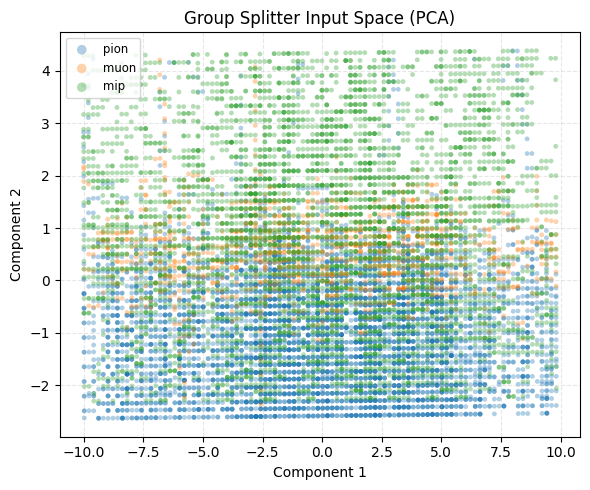

[embedding] Pre-reduced to 7 dims via PCA.


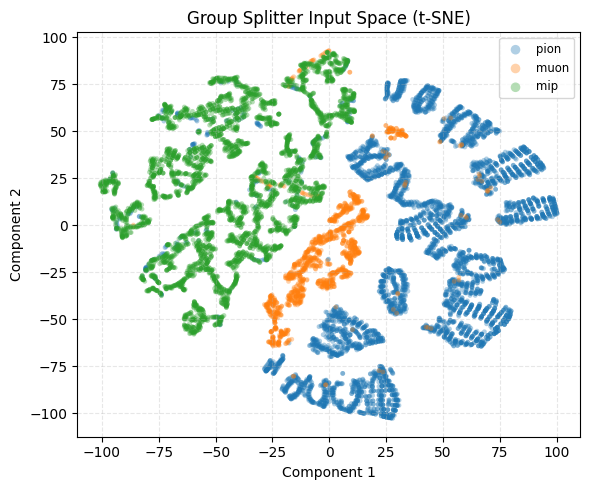

'/workspace/artifacts/validation_plots/group_splitter_embeddings/group_splitter_embeddings_20260326_013003_input_space_tsne.png'

In [5]:
plots_dir = Path(PROJECT_ROOT) / "artifacts" / "validation_plots" / "group_splitter_embeddings"
plots_dir.mkdir(parents=True, exist_ok=True)

timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_prefix = f"group_splitter_embeddings_{timestamp_str}"
class_names = ["pion", "muon", "mip"]

plot_embedding_space(
    embeddings=input_feats,
    targets=input_targets,
    class_names=class_names,
    method="pca",
    title="Group Splitter Input Space (PCA)",
    random_state=42,
    max_samples=max_samples,
    save_path=plots_dir / f"{plot_prefix}_input_space_pca.png",
    show=True,
    verbose=True,
)

plot_embedding_space(
    embeddings=input_feats,
    targets=input_targets,
    class_names=class_names,
    method="tsne",
    title="Group Splitter Input Space (t-SNE)",
    random_state=42,
    max_samples=max_samples,
    pre_pca_components=8,
    save_path=plots_dir / f"{plot_prefix}_input_space_tsne.png",
    show=True,
    verbose=True,
)


## Plot Embedding Space

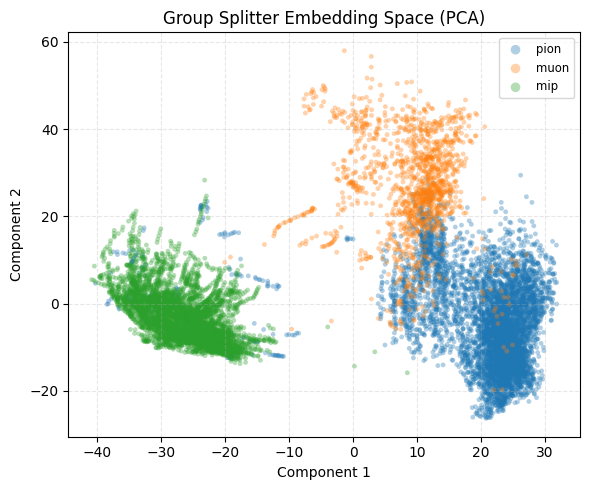

[embedding] Pre-reduced to 50 dims via PCA.


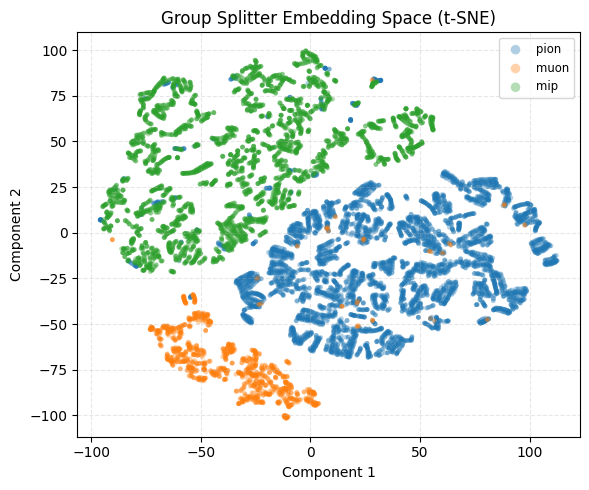

Saved plots to: /workspace/artifacts/validation_plots/group_splitter_embeddings


In [6]:
plot_embedding_space(
    embeddings=embeddings,
    targets=targets,
    class_names=class_names,
    method="pca",
    title="Group Splitter Embedding Space (PCA)",
    random_state=42,
    max_samples=max_samples,
    save_path=plots_dir / f"{plot_prefix}_embedding_space_pca.png",
    show=True,
    verbose=True,
)

plot_embedding_space(
    embeddings=embeddings,
    targets=targets,
    class_names=class_names,
    method="tsne",
    title="Group Splitter Embedding Space (t-SNE)",
    random_state=42,
    max_samples=max_samples,
    pre_pca_components=50,
    save_path=plots_dir / f"{plot_prefix}_embedding_space_tsne.png",
    show=True,
    verbose=True,
)

print(f"Saved plots to: {plots_dir}")


## Interpretation

- If embedding-space clusters separate better than input-space clusters, the model learned useful hit-level structure.
- Persistent overlap in both spaces usually indicates intrinsically ambiguous hits.
